In [1]:
import numpy as np
import pandas as pd
import os
import random
from PIL import Image
from tqdm import tqdm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

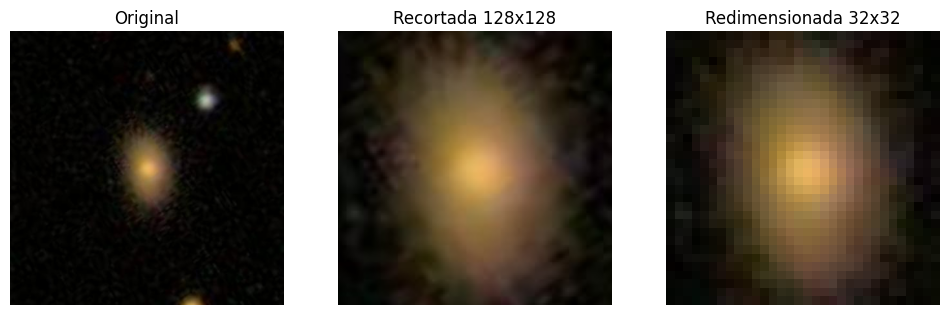

In [23]:
# Visualización de una imagen antes y después de recortar y redimensionar
import matplotlib.pyplot as plt

# Selecciona un nombre de archivo válido
nombre_ejemplo = os.listdir("images_training_rev1")[56803]
ruta = os.path.join("images_training_rev1", nombre_ejemplo)

# Imagen original
img_original = Image.open(ruta)

# Recorte y resize manual para mostrar el proceso
def recortar_y_redimensionar(img, crop_size=(128, 128), resize_to=(32,32)):
    w, h = img.size
    cw, ch = crop_size
    left = (w - cw) // 2
    top = (h - ch) // 2
    img_cropped = img.crop((left, top, left + cw, top + ch))
    img_resized = img_cropped.resize(resize_to)
    return img_cropped, img_resized

img_cropped, img_resized = recortar_y_redimensionar(img_original)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_original)
plt.title('Original')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(img_cropped)
plt.title('Recortada 128x128')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(img_resized)
plt.title('Redimensionada 32x32')
plt.axis('off')
plt.show()

In [2]:
def cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=2000,
    crop_size=(192, 192),
    resize_to=(32, 32)
    ):
    """Carga las mismas imágenes en RGB y en escala de grises, recorta y redimensiona, usando tqdm para mostrar progreso."""
    df = pd.read_csv(archivo_clasificaciones)
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID'.")
    galaxy_ids = df["GalaxyID"].astype(str).tolist()
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)
    print(f"Se seleccionaron {len(archivos_validos)} imágenes para ambos conjuntos.")

    # Cargar en gris
    X_gray, y_gray = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en gris"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L")
            w, h = img.size
            cw, ch = crop_size
            left = (w - cw) // 2
            top = (h - ch) // 2
            img_cropped = img.crop((left, top, left + cw, top + ch))
            img_resized = img_cropped.resize(resize_to)
            X_gray.append(np.array(img_resized))
            y_gray.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (gris): {e}")

    # Cargar en RGB
    X_rgb, y_rgb = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en RGB"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB")
            w, h = img.size
            cw, ch = crop_size
            left = (w - cw) // 2
            top = (h - ch) // 2
            img_cropped = img.crop((left, top, left + cw, top + ch))
            img_resized = img_cropped.resize(resize_to)
            X_rgb.append(np.array(img_resized))
            y_rgb.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (RGB): {e}")

    X_gray = np.array(X_gray)
    X_rgb = np.array(X_rgb)
    print(f"Se cargaron {len(X_gray)} imágenes en gris y {len(X_rgb)} en RGB.")
    return X_gray, y_gray, X_rgb, y_rgb

# Uso:
X_gray, y_gray, X_rgb, y_rgb = cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    max_imagenes=2000,
    archivo_clasificaciones="training_solutions_rev1.csv",
    crop_size=(192, 192),
    resize_to=(32, 32)
    )

Se seleccionaron 2000 imágenes para ambos conjuntos.


Cargando imágenes en RGB: 100%|██████████| 2000/2000 [00:07<00:00, 267.48it/s]

Se cargaron 2000 imágenes en gris y 2000 en RGB.


In [3]:
def cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    archivo_clasificaciones="training_solutions_rev1.csv",
    max_imagenes=2000,
    size=(32, 32)
    ):
    """Carga las mismas imágenes en RGB y en escala de grises, usando tqdm para mostrar progreso."""
    from tqdm import tqdm
    df = pd.read_csv(archivo_clasificaciones)
    if "GalaxyID" not in df.columns:
        raise ValueError("El archivo CSV debe tener una columna 'GalaxyID'.")
    galaxy_ids = df["GalaxyID"].astype(str).tolist()
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    archivos_validos = [f for f in archivos if f.split(".")[0] in galaxy_ids]
    if len(archivos_validos) > max_imagenes:
        archivos_validos = random.sample(archivos_validos, max_imagenes)
    print(f"Se seleccionaron {len(archivos_validos)} imágenes para ambos conjuntos.")

    # Cargar en gris
    X_gray, y_gray = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en gris"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("L").resize(size)
            X_gray.append(np.array(img))
            y_gray.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (gris): {e}")

    # Cargar en RGB
    X_rgb, y_rgb = [], []
    for nombre in tqdm(archivos_validos, desc="Cargando imágenes en RGB"):
        galaxy_id = nombre.split(".")[0]
        fila = df[df["GalaxyID"] == int(galaxy_id)].iloc[0]
        etiqueta = fila.drop("GalaxyID").idxmax()
        ruta = os.path.join(carpeta, nombre)
        try:
            img = Image.open(ruta).convert("RGB").resize(size)
            X_rgb.append(np.array(img))
            y_rgb.append(etiqueta)
        except Exception as e:
            print(f"Error al cargar {nombre} (RGB): {e}")

    X_gray = np.array(X_gray)
    X_rgb = np.array(X_rgb)
    print(f"Se cargaron {len(X_gray)} imágenes en gris y {len(X_rgb)} en RGB.")
    return X_gray, y_gray, X_rgb, y_rgb

# Uso:
X_gray, y_gray, X_rgb, y_rgb = cargar_mismas_imagenes(
    carpeta="images_training_rev1",
    max_imagenes=2000,
    archivo_clasificaciones="training_solutions_rev1.csv",
    size=(32, 32)
    )

Se seleccionaron 2000 imágenes para ambos conjuntos.


Cargando imágenes en RGB: 100%|██████████| 2000/2000 [00:10<00:00, 197.64it/s]

Se cargaron 2000 imágenes en gris y 2000 en RGB.


In [4]:
# --- Preprocesamiento y splits para ambos conjuntos ---

# Aplanar imágenes (cada imagen se convierte en un vector)
X_r_rgb = np.array([img.flatten() for img in tqdm(X_rgb, desc='Aplanando RGB')])
X_r_gray = np.array([img.flatten() for img in tqdm(X_gray, desc='Aplanando Gray')])
print(f"Forma RGB aplanada: {X_r_rgb.shape} | Forma Gray aplanada: {X_r_gray.shape}")

# Codificar etiquetas (usamos las mismas para ambos conjuntos)
le = LabelEncoder()
y_enc = le.fit_transform(y_rgb)
print("Ejemplo etiquetas codificadas:", y_rgb[:5], "->", y_enc[:5])

# División en train/test para ambos conjuntos
from sklearn.model_selection import train_test_split
X_rgb_train, X_rgb_test, y_train, y_test = train_test_split(X_r_rgb, y_enc, test_size=0.3, random_state=40)
X_gray_train, X_gray_test, _, _ = train_test_split(X_r_gray, y_enc, test_size=0.3, random_state=40)
print("Tamaño Train/Test RGB:", X_rgb_train.shape, X_rgb_test.shape)
print("Tamaño Train/Test Gray:", X_gray_train.shape, X_gray_test.shape)
print("Tamaño Etiquetas Train:", y_train.shape, "| Test:", y_test.shape)

Aplanando Gray: 100%|██████████| 2000/2000 [00:00<00:00, 274433.47it/s]

Forma RGB aplanada: (2000, 3072) | Forma Gray aplanada: (2000, 1024)
Ejemplo etiquetas codificadas: ['Class1.1', 'Class6.2', 'Class6.2', 'Class6.2', 'Class6.2'] -> [0 3 3 3 3]
Tamaño Train/Test RGB: (1400, 3072) (600, 3072)
Tamaño Train/Test Gray: (1400, 1024) (600, 1024)
Tamaño Etiquetas Train: (1400,) | Test: (600,)


In [5]:
# --- Definición de pipelines para ambos conjuntos ---
# Puedes cambiar los hiperparámetros si lo deseas
# Pipelines para RGB
logreg_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('logreg', LogisticRegression(C=0.0003, max_iter=10000, solver='lbfgs', random_state=40, class_weight='balanced'))
])

tree_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('tree', DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=20, random_state=40))
])

svm_pipeline_rgb = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=40))
])

# Pipelines para GRAYSCALE
logreg_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('logreg', LogisticRegression(C=0.0003, max_iter=10000, solver='lbfgs', random_state=40, class_weight='balanced'))
])

tree_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('tree', DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=20, random_state=40))
])

svm_pipeline_gray = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=1000, random_state=40)),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=40))
])

In [ ]:
# --- Entrenamiento y evaluación para ambos conjuntos (paralelizado) ---
from joblib import Parallel, delayed

# Función para entrenar y evaluar un pipeline
def entrenar_evaluar(name, pipe, X_train, X_test, y_train, y_test):
    print(f"\nModelo {name}:")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=1))
    return pipe

# Entrenamiento paralelizado para RGB
tasks_rgb = [
    ("LogReg RGB", logreg_pipeline_rgb, X_rgb_train, X_rgb_test, y_train, y_test),
    ("Árbol RGB", tree_pipeline_rgb, X_rgb_train, X_rgb_test, y_train, y_test),
    ("SVM RGB", svm_pipeline_rgb, X_rgb_train, X_rgb_test, y_train, y_test),
]

print("\n--- PIPELINES RGB (paralelizado) ---")
modelos_rgb = Parallel(n_jobs=-1)(delayed(entrenar_evaluar)(*args) for args in tasks_rgb)

# Entrenamiento paralelizado para GRAYSCALE
tasks_gray = [
    ("LogReg Gray", logreg_pipeline_gray, X_gray_train, X_gray_test, y_train, y_test),
    ("Árbol Gray", tree_pipeline_gray, X_gray_train, X_gray_test, y_train, y_test),
    ("SVM Gray", svm_pipeline_gray, X_gray_train, X_gray_test, y_train, y_test),
]

print("\n--- PIPELINES GRAYSCALE (paralelizado) ---")
modelos_gray = Parallel(n_jobs=-1)(delayed(entrenar_evaluar)(*args) for args in tasks_gray)

# Asegurarse de que los pipelines globales estén entrenados para las siguientes celdas
def entrenar_global(pipe, X_train, y_train):
    pipe.fit(X_train, y_train)
    return pipe

logreg_pipeline_rgb = entrenar_global(logreg_pipeline_rgb, X_rgb_train, y_train)
tree_pipeline_rgb = entrenar_global(tree_pipeline_rgb, X_rgb_train, y_train)
svm_pipeline_rgb = entrenar_global(svm_pipeline_rgb, X_rgb_train, y_train)
logreg_pipeline_gray = entrenar_global(logreg_pipeline_gray, X_gray_train, y_train)
tree_pipeline_gray = entrenar_global(tree_pipeline_gray, X_gray_train, y_train)
svm_pipeline_gray = entrenar_global(svm_pipeline_gray, X_gray_train, y_train)



--- PIPELINES RGB (paralelizado) ---

--- PIPELINES GRAYSCALE (paralelizado) ---

--- PIPELINES GRAYSCALE (paralelizado) ---


In [13]:
# --- Matrices de confusión para cada modelo y conjunto ---
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

modelos = [
    ("LogReg RGB", logreg_pipeline_rgb, X_rgb_test),
    ("Árbol RGB", tree_pipeline_rgb, X_rgb_test),
    ("SVM RGB", svm_pipeline_rgb, X_rgb_test),
    ("LogReg Gray", logreg_pipeline_gray, X_gray_test),
    ("Árbol Gray", tree_pipeline_gray, X_gray_test),
    ("SVM Gray", svm_pipeline_gray, X_gray_test),
]

for nombre, modelo, X_test_ in modelos:
    y_pred = modelo.predict(X_test_)
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f"Matriz de confusión\n{nombre}")
    plt.show()


NotFittedError: Pipeline is not fitted yet.

In [11]:
# --- Curvas ROC para cada modelo y conjunto ---
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar etiquetas para ROC (one-vs-rest)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

modelos = [
    ("LogReg RGB", logreg_pipeline_rgb, X_rgb_test),
    ("Árbol RGB", tree_pipeline_rgb, X_rgb_test),
    ("SVM RGB", svm_pipeline_rgb, X_rgb_test),
    ("LogReg Gray", logreg_pipeline_gray, X_gray_test),
    ("Árbol Gray", tree_pipeline_gray, X_gray_test),
    ("SVM Gray", svm_pipeline_gray, X_gray_test),
]

for nombre, modelo, X_test_ in modelos:
    # ROC solo si hay 2 o 3 clases
    if len(classes) <= 3:
        if hasattr(modelo, "predict_proba"):
            y_score = modelo.predict_proba(X_test_)
        else:
            # SVM puede no tener predict_proba, usar decision_function
            y_score = modelo.decision_function(X_test_)
        if len(classes) == 2:
            fpr, tpr, _ = roc_curve(y_test, y_score[:,1])
            roc_auc = auc(fpr, tpr)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
            plt.plot([0,1],[0,1],'k--')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title(f'Curva ROC\n{nombre}')
            plt.legend()
            plt.show()
            print(f"AUC {nombre}: {roc_auc:.4f}")
        else:
            # Multiclase: one-vs-rest
            aucs = []
            for i, clase in enumerate(classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
                roc_auc = auc(fpr, tpr)
                aucs.append(roc_auc)
                plt.plot(fpr, tpr, label=f'Clase {clase} (AUC={roc_auc:.2f})')
            plt.plot([0,1],[0,1],'k--')
            plt.xlabel('FPR')
            plt.ylabel('TPR')
            plt.title(f'Curvas ROC (multiclase)\n{nombre}')
            plt.legend()
            plt.show()
            for i, auc_val in enumerate(aucs):
                print(f"AUC {nombre} - Clase {classes[i]}: {auc_val:.4f}")


In [12]:

print("\n--- PIPELINES GRAYSCALE ---")
for name, pipe in zip(["LogReg", "Árbol", "SVM"], [logreg_pipeline_gray, tree_pipeline_gray, svm_pipeline_gray]):
    print(f"\nModelo {name} (Gray):")
    pipe.fit(X_gray_train, y_train)
    y_pred = pipe.predict(X_gray_test)
    print(classification_report(y_test, y_pred, zero_division=1))


--- PIPELINES GRAYSCALE ---

Modelo LogReg (Gray):
              precision    recall  f1-score   support

           0       0.13      0.18      0.15        57
           1       0.41      0.62      0.50       172
           2       0.09      0.24      0.13        33
           3       0.69      0.35      0.46       338

    accuracy                           0.40       600
   macro avg       0.33      0.35      0.31       600
weighted avg       0.52      0.40      0.42       600


Modelo Árbol (Gray):
              precision    recall  f1-score   support

           0       0.13      0.18      0.15        57
           1       0.41      0.62      0.50       172
           2       0.09      0.24      0.13        33
           3       0.69      0.35      0.46       338

    accuracy                           0.40       600
   macro avg       0.33      0.35      0.31       600
weighted avg       0.52      0.40      0.42       600


Modelo Árbol (Gray):
              precision    recall 

In [1]:
# --- Métricas de train y test para modelos GRAY y comparación gráfica ---
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular métricas para train y test
metricas = ["accuracy", "precision", "recall", "f1-score", "precision_weighted", "recall_weighted", "f1-score_weighted"]
modelos = [
    ("LogReg Gray", logreg_pipeline_gray),
    ("Árbol Gray", tree_pipeline_gray),
    ("SVM Gray", svm_pipeline_gray),
]

resultados = []
for nombre, modelo in modelos:
    # Train
    y_pred_train = modelo.predict(X_gray_train)
    report_train = classification_report(y_train, y_pred_train, output_dict=True, zero_division=1)
    # Test
    y_pred_test = modelo.predict(X_gray_test)
    report_test = classification_report(y_test, y_pred_test, output_dict=True, zero_division=1)
    # Guardar métricas globales
    resultados.append({
        "Modelo": nombre,
        "Tipo": "Train",
        **{m: report_train["macro avg"][m] if m!="accuracy" else report_train["accuracy"] for m in metricas[:4]},
        **{m: report_train["weighted avg"][m.replace("_weighted","")] for m in metricas[4:]}
    })
    resultados.append({
        "Modelo": nombre,
        "Tipo": "Test",
        **{m: report_test["macro avg"][m] if m!="accuracy" else report_test["accuracy"] for m in metricas[:4]},
        **{m: report_test["weighted avg"][m.replace("_weighted","")] for m in metricas[4:]}
    })

# DataFrame para graficar
res_df = pd.DataFrame(resultados)

# Gráfica comparativa
plt.figure(figsize=(12,6))
sns.barplot(data=res_df.melt(id_vars=["Modelo","Tipo"], value_vars=metricas), x="variable", y="value", hue="Tipo", ci=None, palette="muted")
plt.title("Comparación de métricas globales (Train vs Test) para modelos Gray")
plt.ylabel("Valor métrica")
plt.xlabel("Métrica global")
plt.legend(title="Conjunto")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

NameError: name 'logreg_pipeline_gray' is not defined